### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

# TEAM / REGRAGUI ILYASS , EL HANAFY AYMEN , LEO ZEHNTER SAINT-CHARLES

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***


### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

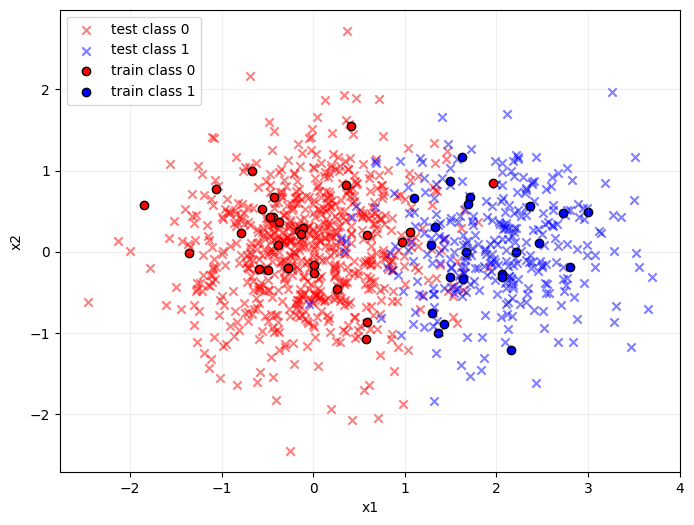

In [34]:
from numpy.random import multivariate_normal, rand
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # pour reproductibilité

train_0, train_1, test_0, test_1 = [], [], [], []

mu0 = np.array([0, 0])
mu1 = np.array([2, 0])
cov0 = np.array([[0.5, 0], [0, 0.5]])
cov1 = np.array([[0.4, 0], [0, 0.4]])

for _ in range(50):
    y = int(rand() < 0.3)
    x = multivariate_normal(mu1, cov1) if y == 1 else multivariate_normal(mu0, cov0)
    (train_1 if y == 1 else train_0).append(x)

for _ in range(1000):   # <- 1000 (10^3), pas 10000
    y = int(rand() < 0.3)
    x = multivariate_normal(mu1, cov1) if y == 1 else multivariate_normal(mu0, cov0)
    (test_1 if y == 1 else test_0).append(x)

train_0, train_1 = np.array(train_0), np.array(train_1)
test_0, test_1 = np.array(test_0), np.array(test_1)

plt.figure(figsize=(8,6))
plt.scatter(test_0[:,0], test_0[:,1], marker='x', c='red',  alpha=0.5, label='test class 0')
plt.scatter(test_1[:,0], test_1[:,1], marker='x', c='blue', alpha=0.5, label='test class 1')
plt.scatter(train_0[:,0], train_0[:,1], marker='o', c='red',  edgecolors='k', label='train class 0')
plt.scatter(train_1[:,0], train_1[:,1], marker='o', c='blue', edgecolors='k', label='train class 1')
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

**Response (b)**

We consider:
$$
X \mid Y=0 \sim \mathcal{N}(\mu_0,\Sigma_0),
\qquad
X \mid Y=1 \sim \mathcal{N}(\mu_1,\Sigma_1),
$$
with priors:
$$
\mathbb{P}(Y=1)=p,
\qquad
\mathbb{P}(Y=0)=1-p.
$$

The optimal Bayes classifier is:
$$
\hat{y}_{\mathrm{Bayes}}(x)
=
\arg\max_{k \in \{0,1\}}
\mathbb{P}(Y=k \mid X=x).
$$

Equivalently:
$$
\hat{y}_{\mathrm{Bayes}}(x)=1
\iff
\frac{\mathbb{P}(Y=1 \mid x)}
{\mathbb{P}(Y=0 \mid x)}
\ge 1.
$$

Using Bayes' rule:
$$
\frac{\mathbb{P}(Y=1 \mid x)}
{\mathbb{P}(Y=0 \mid x)}
=
\frac{p\,f_1(x)}{(1-p)\,f_0(x)},
$$
where
$$
f_k(x)
=
\frac{1}{2\pi\sqrt{\det(\Sigma_k)}}
\exp\!\left(
-\frac{1}{2}(x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k)
\right).
$$

Therefore:
$$
\hat{y}_{\mathrm{Bayes}}(x)=1
\iff
(x-\mu_1)^\top \Sigma_1^{-1}(x-\mu_1)
-
(x-\mu_0)^\top \Sigma_0^{-1}(x-\mu_0)
\le
2\ln\!\left(
\frac{p}{1-p}
\sqrt{\frac{\det(\Sigma_0)}{\det(\Sigma_1)}}
\right).
$$

The decision boundary is:
$$
\partial\mathcal{C}
=
\left\{
x\in\mathbb{R}^2:
\frac{\mathbb{P}(Y=1\mid x)}{\mathbb{P}(Y=0\mid x)}=1
\right\}
=
\left\{
x:\ p\,f_1(x)=(1-p)\,f_0(x)
\right\}.
$$

For this TP:
$$
\mu_0=(0,0),
\qquad
\mu_1=(\varepsilon,0),
\qquad
\Sigma_0=0.5I_2,
\qquad
\Sigma_1=0.4I_2.
$$
So:
$$
\Sigma_0^{-1}=2I_2,
\qquad
\Sigma_1^{-1}=2.5I_2,
\qquad
\sqrt{\frac{\det(\Sigma_0)}{\det(\Sigma_1)}}=\frac{5}{4}.
$$

Hence:
$$
\hat{y}_{\mathrm{Bayes}}(x)=1
\iff
\frac{5}{4}(x_1-\varepsilon)^2
-
x_1^2
+
\frac{x_2^2}{4}
\le
\ln\!\left(\frac{5p}{4(1-p)}\right).
$$

Boundary equation:
$$
\frac{5}{4}(x_1-\varepsilon)^2
-
x_1^2
+
\frac{x_2^2}{4}
=
\ln\!\left(\frac{5p}{4(1-p)}\right).
$$

Equivalent form:
$$
(x_1-5\varepsilon)^2+x_2^2
=
20\varepsilon^2
+
4\ln\!\left(\frac{5p}{4(1-p)}\right).
$$

So in this setup, the Bayes boundary is a quadratic curve (here, a circle).


**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

**Reponse (c)**: Our goal for this question is to create a Bayes classifier knowing the parameters used to create our dataset. As the dataset created follow a gaussian distribution we can use a generative approach and try to maxime $$f(x_0) = \arg\max_{k \in \{1, 0\}} P(Y = k) P(x_0 | Y=k)$$
with $$P(x_0 | Y=k) =\frac{1}{(2 \pi)^{p/2}} \frac{1}{det(\Sigma_{k})^{1/2}} exp(- \frac{1}{2}(x_0 - \mu_{k})^{T} \Sigma_{k}^{-1} (x_0 - \mu_{k}))$$

In our code we will try to maximize $ln(P(Y = k) P(x_0 | Y=k))$ because it is equivalent to maximizing $P(Y = k) P(x_0 | Y=k)$ and make easier the calculations. We will choose the value of $k$ which maximize : $$- \frac{1}{2} \left[ (x_0 - \mu_{k})^{T} \Sigma_{k}^{-1} (x_0 - \mu_{k}) - ln(det(\Sigma_{k}))\right] + ln(P(Y = k))$$

Our classifier will follow the scikit-learn API, with a method `predict` which return a prediction vector for a dataset given at input and a `fit` method which approximate the parameters of the model with a train dataset. The particularity of our classifier is that is specially made for 2 classes and that we can precise the parameters of generation thansk to the instanciation method `__init__`. If parameters have been set at instanciation, the given parameters will be used to make predictions, if not the model will try to use the parameters calculated by approximation.

In [35]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import validate_data, check_array, check_is_fitted
from sklearn.utils.multiclass import unique_labels

class BayesClassfier(BaseEstimator, ClassifierMixin):
        
        def __init__(self, mu0=None, mu1=None,
                 Sigma0=None, Sigma1=None,
                 pi0=0.5, pi1=0.5, classes=[0,1]):
            """Make able to define a set of parameters known by the user which will not be changed by fitting and will be used
            in priority to make the predictions"""
            self.mu0 = mu0
            self.mu1 = mu1
            self.Sigma0 = Sigma0
            self.Sigma1 = Sigma1
            self.pi0 = pi0
            self.pi1 = pi1
            self.classes_ = classes

        def fit(self, X, y):
            """
            Here we estimate parameters from data.
            """
            # Storing the X, y of fitting
            X,y = validate_data(self, X, y)
            self.classes_ = unique_labels(y)
            self.X_ = X
            self.y_ = y

            # Separation in two classes
            X0 = X[y==self.classes_[0]]
            X1 = X[y==self.classes_[1]]

            # Calculating covariance and mean for the two classes
            self.mu0_ = X0.mean(axis=0)
            self.mu1_ = X1.mean(axis=0)
            self.Sigma0_ = np.cov(X0,rowvar=False)
            self.Sigma1_ = np.cov(X1,rowvar=False)

            # Inversion of the covariance matrix
            self.inv0_ = np.linalg.inv(self.Sigma0_)
            self.inv1_ = np.linalg.inv(self.Sigma1_)

            # Calculate logarithm of determinant of covariance
            _, self.logdet0_ = np.linalg.slogdet(self.Sigma0_)
            _, self.logdet1_ = np.linalg.slogdet(self.Sigma1_)

            # Calculating prior probability distribution
            self.pi0_ = len(X0)/len(X)
            self.pi1_ = len(X1)/len(X)

            return self
        
        def _discri_score(self, X, mu, invS, logdet, prior):
            """Return discriminant score as define earlier"""
            # Function which calculate the discriminant score
            diff = X-mu
            quad = np.sum((diff @ invS)*diff, axis=1)
            return -0.5*quad -0.5*logdet + np.log(prior)

        def check_oracle(self):
            """This method return True all the oracle paramters are set"""
            return not((self.mu0 is None) or (self.Sigma0 is None) or (self.mu1 is None) or (self.Sigma1 is None))

        def predict(self,X):
            """Function which generates the prediction vector for the dataset X"""
            if self.check_oracle():
                # Here we use the values specified to make the predictions
                # Calculate our two probabilities 
                logP0=self._discri_score(X,self.mu0,np.linalg.inv(self.Sigma0),np.linalg.slogdet(self.Sigma0)[1],self.pi0)
                logP1=self._discri_score(X,self.mu1,np.linalg.inv(self.Sigma1),np.linalg.slogdet(self.Sigma1)[1],self.pi1)
            else:
                # Here we use the values aprroximated to make the predictions
                # Check is the model has been fitted
                check_is_fitted(self,["mu0_","mu1_"])

                # Check if the features matrix is valid
                X=check_array(X)

                # Calculate our two probabilities 
                logP0=self._discri_score(X,self.mu0_,self.inv0_,self.logdet0_,self.pi0_)
                logP1=self._discri_score(X,self.mu1_,self.inv1_,self.logdet1_,self.pi1_)

            # Generates the predictions vector
            is1 = logP1 > logP0
            res = []
            for i in range(0,len(is1)):
                if is1[i]:
                    # If logP1 > logP0 we are in the class 1
                    res.append(self.classes_[1])
                else:
                    res.append(self.classes_[0])
            return res
        
def calculate_error(preds, reals):
    """ Function which calculate mean error for two classes classfier."""
    error = 0
    for i in range(len(preds)):
        error += abs(preds[i] - reals[i])
    return error/len(preds)
    

In [36]:
bays_model = BayesClassfier(mu0=mu1, mu1=mu2, Sigma0=cov1, Sigma1=cov2, pi0=0.7, pi1=0.3)
y_test = np.array(len(test_0)*[0] + len(test_1)*[1])
predictions = bays_model.predict(np.array(test_0+test_1))

print("Final error is :",calculate_error(predictions, y_test))

ValueError: operands could not be broadcast together with shapes (702,2) (298,2) 

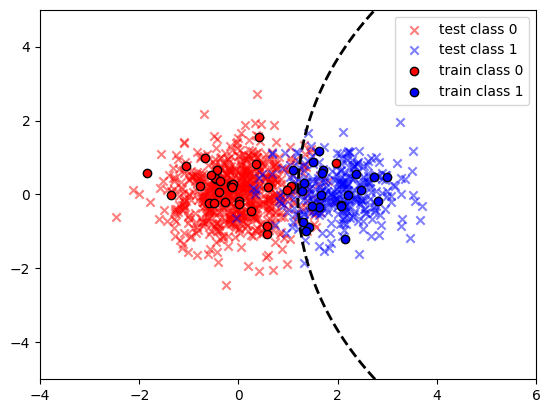

In [ ]:
plt.scatter(test_0[:,0], test_0[:,1], marker='x', c='red',  alpha=0.5, label='test class 0')
plt.scatter(test_1[:,0], test_1[:,1], marker='x', c='blue', alpha=0.5, label='test class 1')
plt.scatter(train_0[:,0], train_0[:,1], marker='o', c='red',  edgecolors='k', label='train class 0')
plt.scatter(train_1[:,0], train_1[:,1], marker='o', c='blue', edgecolors='k', label='train class 1')

xx, yy = np.meshgrid(np.linspace(-4, 6, 300), np.linspace(-5, 5, 300))
Z = 1.25*(xx - 2)**2 - xx**2 + 0.25*yy**2 - np.log((5*0.3)/(4*(1-0.3)))
plt.contour(xx, yy, Z, levels=[0], colors='k', linestyles='--', linewidths=2)

plt.legend()
plt.show()


When increasing the value $\epsilon$, the center of the two distribution move away from each other. The superposition of the classes are decreased so the Bayes error is decreased too. The following code and the following plot demonstrates it by plotting the Byaes error function of the paramteter epsilon.

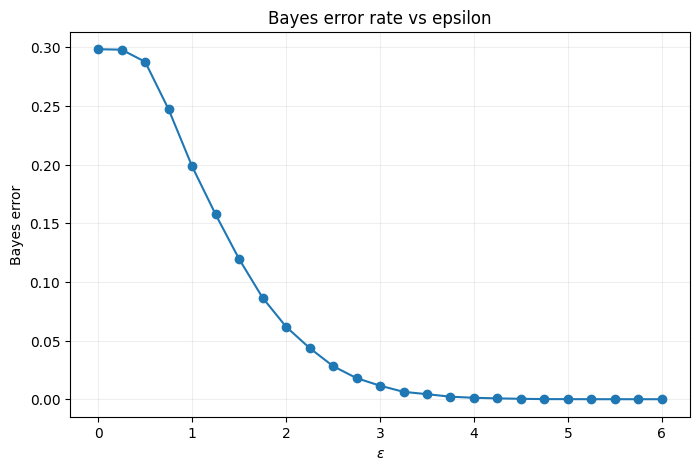

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import multivariate_normal

np.random.seed(42)

def generate_test_data(epsilon, p, test_len):
    mu0 = np.array([0.0, 0.0])
    mu1 = np.array([epsilon, 0.0])
    cov0 = np.array([[0.5, 0.0], [0.0, 0.5]])
    cov1 = np.array([[0.4, 0.0], [0.0, 0.4]])

    y = (np.random.rand(test_len) < p).astype(int)
    X = np.empty((test_len, 2))

    n1 = np.sum(y == 1)
    n0 = test_len - n1
    X[y == 1] = multivariate_normal(mu1, cov1, size=n1)
    X[y == 0] = multivariate_normal(mu0, cov0, size=n0)

    params = {
        "mu0": mu0, "mu1": mu1,
        "cov0": cov0, "cov1": cov1,
        "P0": 1 - p, "P1": p
    }
    return X, y, params

eps_grid = np.linspace(0, 6, 25)
errors = []

n_rep = 20
for eps in eps_grid:
    rep_errors = []
    for _ in range(n_rep):
        X_test, y_test, params = generate_test_data(eps, p=0.3, test_len=5000)

        model = BayesClassfier(
            mu0=params["mu0"], mu1=params["mu1"],
            Sigma0=params["cov0"], Sigma1=params["cov1"],
            pi0=params["P0"], pi1=params["P1"]
        )  # pas besoin de fit ici (oracle)

        y_pred = np.array(model.predict(X_test))
        rep_errors.append(calculate_error(y_pred, y_test))

    errors.append(np.mean(rep_errors))

plt.figure(figsize=(8, 5))
plt.plot(eps_grid, errors, marker='o')
plt.xlabel(r"$\varepsilon$")
plt.ylabel("Bayes error")
plt.title("Bayes error rate vs epsilon")
plt.grid(alpha=0.2)
plt.show()


**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

**Response (d)**

The most adequate classifier is **QDA (Quadratic Discriminant Analysis)**.

Reason: in our data-generating model, each class conditional distribution is Gaussian:
$$
X\mid Y=0 \sim \mathcal N(\mu_0,\Sigma_0),\qquad
X\mid Y=1 \sim \mathcal N(\mu_1,\Sigma_1),
$$
and the covariance matrices are different:
$$
\Sigma_0 \neq \Sigma_1.
$$

QDA is exactly built for this setting:
- it assumes Gaussian class-conditionals;
- it allows one covariance matrix per class;
- it gives a quadratic decision boundary, which matches the Bayes-optimal structure in this TP.

By contrast:
- **LDA** assumes
$$
\Sigma_0=\Sigma_1,
$$
which is violated here;
- **Logistic regression** is discriminative and imposes a linear log-odds boundary, so it is generally misspecified in this setting;
- **Naive Bayes** assumes conditional independence of features, which is not the core assumption of our generator.

Therefore, based on model assumptions, **QDA is the most appropriate practical classifier and the closest to the Bayes rule** for this problem.


**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [ ]:


from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis

np.random.seed(42)

# D_train = D(50 | 2, 0.3), D_test = D(1000 | 2, 0.3)
X_train, y_train, X_test, y_test, params = generate_data(2, 0.3, 50, 1000)

bayes_model = BayesClassfier(
    params["mu0"], params["mu1"],
    params["cov0"], params["cov1"],
    params["P0"], params["P1"]
)

models = {
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=1e-4),
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
}

errors = {"Bayes (oracle)": calculate_error(bayes_model.predict(X_test), y_test)}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    errors[name] = calculate_error(preds, y_test)

# Affichage propre des test errors
errors_df = pd.DataFrame.from_dict(errors, orient="index", columns=["Test error"]).sort_values("Test error")
print(errors_df)


                     Test error
Logistic Regression       0.062
Bayes (oracle)            0.065
QDA                       0.069
LDA                       0.073


**Response (e)**: The errors calculated for LDA, QDA and Linear Regression are higher than the one predicted with out Bayes classifier what is normal because the Bayes classifier is the optimal classifier for the data generated.

If we increase the size of $\mathcal{D}_{\text{train}}$ samples :
- For **QDA** the gap will continue decrease to 0 because the approximations of the distribution parameters will be better.
- For **LDA** the gap will decrease but will stop at a precise level because the method of generation of the samples it is not valid with the hypothesis of same covariance made by LDA. The biais will not desapear.
- For **Linear Regression** : It will follow he same principal as LDA, the variance will decrease but not the biais.

The following code will show what we are saying.

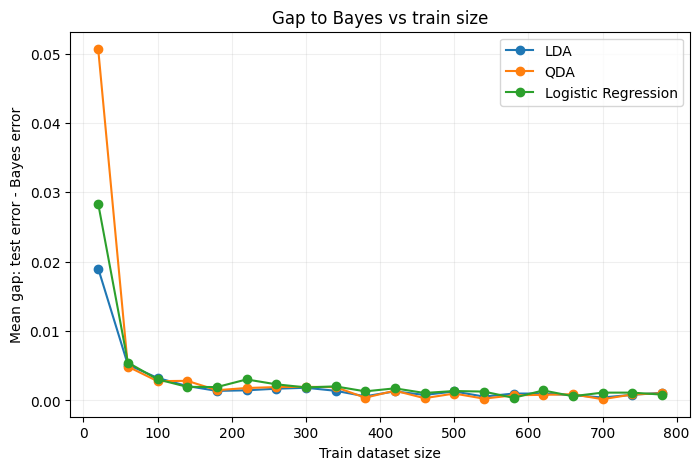

In [ ]:
error_gap = {'LDA': [], 'QDA': [], 'Logistic Regression': []}
size_grid = np.arange(20, 801, 40)
n_rep = 30

for train_len in size_grid:
    gaps = {'LDA': [], 'QDA': [], 'Logistic Regression': []}

    for _ in range(n_rep):
        # Regenerate data each time (more robust)
        X_train, y_train, X_test, y_test, p = generate_data(2, 0.3, int(train_len), 2000)

        # Ensure both classes exist in train
        if np.bincount(y_train, minlength=2).min() < 2:
            continue

        bayes = BayesClassfier(p['mu0'], p['mu1'], p['cov0'], p['cov1'], p['P0'], p['P1'])
        e_bayes = calculate_error(bayes.predict(X_test), y_test)

        lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
        qda = QuadraticDiscriminantAnalysis(reg_param=1e-4).fit(X_train, y_train)
        lr = LogisticRegression(max_iter=3000).fit(X_train, y_train)

        gaps['LDA'].append(calculate_error(lda.predict(X_test), y_test) - e_bayes)
        gaps['QDA'].append(calculate_error(qda.predict(X_test), y_test) - e_bayes)
        gaps['Logistic Regression'].append(calculate_error(lr.predict(X_test), y_test) - e_bayes)

    for k in error_gap:
        error_gap[k].append(np.mean(gaps[k]) if len(gaps[k]) > 0 else np.nan)

plt.figure(figsize=(8,5))
for k in error_gap:
    plt.plot(size_grid, error_gap[k], marker='o', label=k)
plt.xlabel("Train dataset size")
plt.ylabel("Mean gap: test error - Bayes error")
plt.title("Gap to Bayes vs train size")
plt.grid(alpha=0.2)
plt.legend()
plt.show()


As foreseen, we can observe than the LDA classifier decreased then re-increased a litter bit before staying a nearly same level. The QDA continued to decreased progesively where the gap for the Linear Regression seems to be more variable. 

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [ ]:
_,_, X_test, y_test, dict_parameters = generate_data(0.5, 0.7, 0, 1000)

bays_model = BayesClassfier(dict_parameters['mu0'],dict_parameters['mu1'],dict_parameters['cov0'],dict_parameters['cov1'],dict_parameters['P0'],dict_parameters['P1'])

errors2 = {}
preds = lda.predict(X_test)
errors2['LDA'] = calculate_error(preds,y_test)

preds = qda.predict(X_test)
errors2['QDA'] = calculate_error(preds,y_test)

preds = lr.predict(X_test)
errors2['Linear Regression'] = calculate_error(preds,y_test)

print(errors2)
print("Bayes error for this dataset : ", calculate_error(bays_model.predict(X_test),y_test))
    

{'LDA': np.float64(0.653), 'QDA': np.float64(0.673), 'Linear Regression': np.float64(0.674)}
Bayes error for this dataset :  0.258


**Response (f)**: We can see here than the results of the different models have greatly increased because the parameters of the dataset generated don't match with the ones of the dataset on which the models have been trained. A part of this increase is also linked with the decreased fo the $\epsilon$ value which increase the Bayes error as printed. Then the change of the probability $p$ don't help to better our predictions because on the area where the data overlap the models tend to predict the most frequent class which is no longer the class 1. 

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

### Titanic: Feature Engineering Strategy

To improve prediction quality, I designed the preprocessing in several passes, starting from a simple baseline and adding features only when they brought useful signal.

The baseline model used only a few numeric columns (`Fare`, `SibSp`, `Parch`).  
After that, I expanded the pipeline with the following steps:

- **Categorical processing**  
  Variables such as `Pclass`, `Sex`, and `Embarked` were converted into machine-readable inputs using one-hot encoding.

- **Missing data treatment**  
  `Age` was completed with median imputation; missing categorical values were filled with the most frequent category.  
  This allowed me to keep all passengers in the training set.

- **Household-related variables**  
  I created:
  - `FamilySize = SibSp + Parch + 1`
  - `IsAlone = 1(FamilySize == 1)`  
  These features capture whether a passenger traveled in a group or alone, which is informative for survival.

- **Rule-inspired indicator**  
  I added `Child = 1(Age < 8)` to model the child-priority evacuation effect.

- **Information extracted from text columns**  
  From `Name`, I extracted the passenger title (e.g., Mr, Mrs, Miss).  
  From `Cabin`, I kept the first character to represent deck location.  
  Both were then encoded as categorical variables.

- **Dropping noisy raw columns**  
  Once useful signals were extracted, raw text fields with high cardinality (`Name`, `Ticket`, original `Cabin`) were removed to reduce noise and overfitting risk.

In summary, the final representation combines cleaned numeric features, encoded categorical variables, and domain-based engineered features, giving a clear improvement over the initial baseline.


**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

**Response (b)**

I ended up using a **Gradient Boosting classifier** as my final model.

I chose this classifier because Titanic is a tabular dataset with mixed feature types and nonlinear interactions (for example between `Sex`, `Pclass`, `Age`, and family-related features). Gradient Boosting usually handles these interactions better than a purely linear model, while remaining robust on small/medium-sized datasets.

After feature engineering and preprocessing, this model gave the best validation performance among the candidates I tested, so I used it for the Kaggle submission.

My public Kaggle leaderboard score was: **`0.76794`**.
